# 🏢 Notebook 03: Decomposição STL e Projeção de Consumo do Subgrupo B3 (Comercial)
**Disciplina**: Técnicas de IA Aplicadas a Sistemas de Energia
**Programa**: Mestrado Profissional — IFSC
**Autor**: Dilsonei José Rigotti

---

## 🎯 Objetivo
Aplicar a decomposição STL ao consumo mensal do Subgrupo B3 Comercial Cativo (Seção V.D do
relatório) e gerar a previsão de consumo até dezembro de 2030 (57 meses à frente, Seção VI),
usada como insumo da simulação financeira do Notebook 04.

> **Nota de versão:** Este notebook assume o LSTM como modelo de projeção, por ser o modelo
> a ser aplicado por decisão do autor e para este trabalho (Seção V.C do relatório)
> a validação walk-forward do Notebook 02  mostra que o Holt-Winters é, na verdade,
> o modelo estatisticamente mais robusto; essa divergência é discutida no relatório
> como parte da análise crítica do exercício, e não é reproduzida aqui.

In [1]:
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL

import tensorflow as tf
from tensorflow import keras

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

os.makedirs("../results/plots", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)
print("Imports OK")

Imports OK


## 1. Carregamento dos Dados do Subgrupo B3 Comercial (1994–2026)

In [2]:
def carregar_serie_b3_cativo():
    caminho_novo = "../data/processed/b3_cativo_mensal.csv"
    caminho_legado = "../data/processed/Subgrupo_B3_Comercial_Tratado_1994_2026_B3_Cativo.csv"

    if os.path.exists(caminho_novo):
        df = pd.read_csv(caminho_novo)
    else:
        df = pd.read_csv(caminho_legado, sep=";", decimal=",", encoding="utf-8-sig")

    df["data"] = pd.to_datetime({"year": df["ano"], "month": df["mes"], "day": 1})
    df = df.sort_values("data").reset_index(drop=True)
    df_ts = df.set_index("data")
    ts_b3 = df_ts["consumo_mwh"].asfreq("MS").interpolate(method="linear")
    return ts_b3


ts_b3 = carregar_serie_b3_cativo()
print(f"Total de meses B3: {len(ts_b3)} (de {ts_b3.index[0]:%Y-%m} a {ts_b3.index[-1]:%Y-%m})")
ts_b3.head()

Total de meses B3: 376 (de 1994-12 a 2026-03)


data
1994-12-01    76256.101
1995-01-01    81750.261
1995-02-01    79815.154
1995-03-01    85568.733
1995-04-01    81782.544
Freq: MS, Name: consumo_mwh, dtype: float64

## 2. Decomposição STL do Consumo Comercial B3

Decomposição aditiva da série temporal Y_t = T_t + S_t + R_t, separando a série mensal contínua
de 387 meses (jan/1994–mar/2026) em tendência, sazonalidade e resíduo (Seção V.D do relatório).

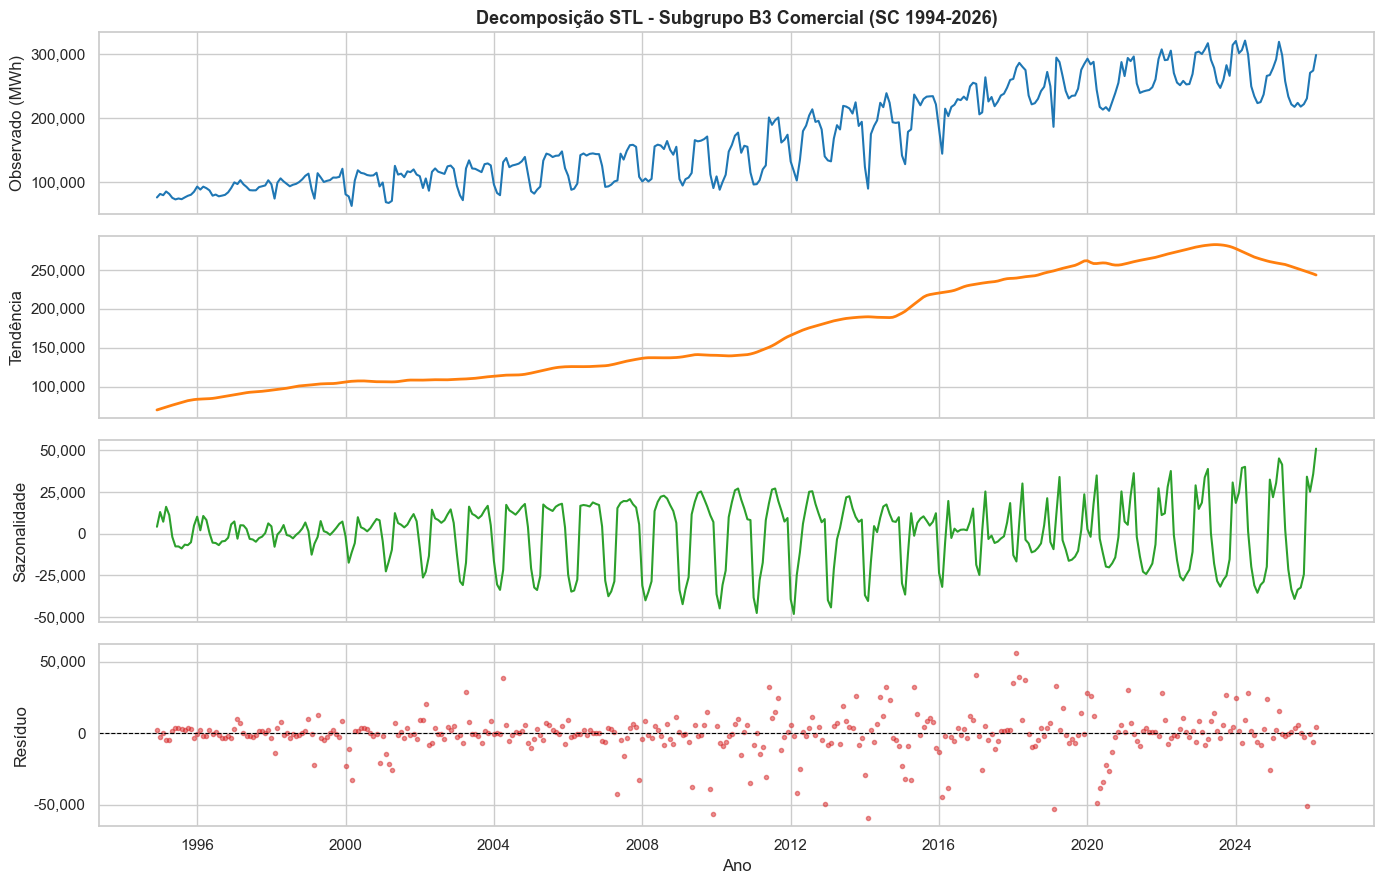

Figura salva: results/plots/03_stl_b3_comercial.png


In [3]:
stl = STL(ts_b3, seasonal=13, robust=True)
res = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
axes[0].plot(res.observed, color="#1f77b4", linewidth=1.5)
axes[0].set_ylabel("Observado (MWh)")
axes[0].set_title("Decomposição STL - Subgrupo B3 Comercial (SC 1994-2026)", fontsize=13, fontweight="bold")

axes[1].plot(res.trend, color="#ff7f0e", linewidth=2)
axes[1].set_ylabel("Tendência")

axes[2].plot(res.seasonal, color="#2ca02c", linewidth=1.5)
axes[2].set_ylabel("Sazonalidade")

axes[3].plot(res.resid, color="#d62728", marker=".", linestyle="None", alpha=0.5)
axes[3].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[3].set_ylabel("Resíduo")
axes[3].set_xlabel("Ano")

for ax in axes:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("../results/plots/03_stl_b3_comercial.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva: results/plots/03_stl_b3_comercial.png")

In [4]:
def forca_tendencia(res):
    return max(0, 1 - np.var(res.resid) / np.var(res.trend + res.resid))


def forca_sazonalidade(res):
    return max(0, 1 - np.var(res.resid) / np.var(res.seasonal + res.resid))


ft = forca_tendencia(res)
fs = forca_sazonalidade(res)

tabela_stl = pd.DataFrame([{
    "Classe": "Comercial (B3)",
    "FT": round(ft, 4),
    "FS": round(fs, 4),
}])

with open("../data/processed/stl_metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump({"FT": ft, "FS": fs}, f, ensure_ascii=False, indent=2)

print("TABELA II — Força de Tendência e Sazonalidade (Decomposição STL, Subgrupo B3)")
print(tabela_stl.to_string(index=False))

TABELA II — Força de Tendência e Sazonalidade (Decomposição STL, Subgrupo B3)
        Classe     FT     FS
Comercial (B3) 0.9564 0.6671


## 3. Previsão de Consumo B3 até Dezembro de 2030 (Seção VI do relatório)

O modelo LSTM (mesma arquitetura do Notebook 02: LSTM(32) + Dense(16, ReLU) + saída linear,
janela deslizante de 12 meses, normalização z-score ajustada apenas no treino, Adam lr=0,005) é
retreinado com **todo o histórico disponível** (dez/1994–mar/2026) para gerar a previsão recursiva
mensal até dezembro de 2030 (57 meses à frente). Os últimos 24 meses da série servem de validação
para early stopping.

In [5]:
N_LAGS = 12
JANELA_LSTM = 12


def criar_janelas(valores, janela=JANELA_LSTM):
    X, y = [], []
    for i in range(janela, len(valores)):
        X.append(valores[i - janela:i])
        y.append(valores[i])
    return np.array(X), np.array(y)


def fit_forecast_lstm(serie_treino, serie_validacao, n_passos, janela=JANELA_LSTM, epochs=150, verbose=0):
    media, desvio = serie_treino.mean(), serie_treino.std()
    treino_norm = (serie_treino - media) / desvio

    tem_validacao = serie_validacao is not None and len(serie_validacao) > 0
    if tem_validacao:
        val_norm = (serie_validacao - media) / desvio
        serie_val_completa = pd.concat([treino_norm.iloc[-janela:], val_norm])
        X_val, y_val = criar_janelas(serie_val_completa.values, janela)
        X_val = X_val.reshape((-1, janela, 1))
        dados_validacao = (X_val, y_val)
    else:
        val_norm = pd.Series(dtype=float)
        dados_validacao = None

    X_train, y_train = criar_janelas(treino_norm.values, janela)
    X_train = X_train.reshape((-1, janela, 1))

    tf.random.set_seed(RANDOM_STATE)
    modelo = keras.Sequential([
        keras.layers.Input(shape=(janela, 1)),
        keras.layers.LSTM(32),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(1),
    ])
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005), loss="mse")

    callbacks = []
    if dados_validacao is not None:
        callbacks.append(keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True))

    historico_treino = modelo.fit(
        X_train, y_train,
        validation_data=dados_validacao,
        epochs=epochs, batch_size=16,
        callbacks=callbacks, verbose=verbose,
    )

    historico_norm = list(treino_norm.values) + list(val_norm.values)
    janela_atual = historico_norm[-janela:]
    previsoes_norm = []
    for _ in range(n_passos):
        x_in = np.array(janela_atual[-janela:]).reshape((1, janela, 1))
        y_hat = float(modelo.predict(x_in, verbose=0)[0, 0])
        previsoes_norm.append(y_hat)
        janela_atual.append(y_hat)

    ultima_data = serie_validacao.index[-1] if tem_validacao else serie_treino.index[-1]
    datas_futuras = pd.date_range(ultima_data + pd.offsets.MonthBegin(1), periods=n_passos, freq="MS")
    previsoes = np.array(previsoes_norm) * desvio + media
    incerteza_mape = np.mean(np.abs(historico_treino.history.get("val_loss", historico_treino.history["loss"])))
    return pd.Series(previsoes, index=datas_futuras), modelo


print("Função de projeção LSTM definida.")

Função de projeção LSTM definida.


In [6]:
MESES_VALIDACAO = 24
FIM_PROJECAO = "2030-12-01"

sub_treino = ts_b3.iloc[:-MESES_VALIDACAO]
sub_validacao = ts_b3.iloc[-MESES_VALIDACAO:]
n_passos = len(pd.date_range(ts_b3.index[-1] + pd.offsets.MonthBegin(1), FIM_PROJECAO, freq="MS"))

print(f"Retreinando LSTM com todo o histórico (validação: últimos {MESES_VALIDACAO} meses para early stopping)")
print(f"Horizonte de projeção: {n_passos} meses ({(ts_b3.index[-1] + pd.offsets.MonthBegin(1)):%Y-%m} a {FIM_PROJECAO[:7]})")

previsao_lstm, modelo_final = fit_forecast_lstm(sub_treino, sub_validacao, n_passos, epochs=150)

# MAPE walk-forward do Holt-Winters (Notebook 02, Tabela IV) usado como heurística de incerteza,
# por ser a validação mais robusta disponível (21 janelas) — ver Seção VI do relatório.
# Lido do arquivo gerado pelo Notebook 02, para manter os dois notebooks sempre consistentes.
caminho_tabela4 = "../data/processed/tabela4_walkforward.json"
if not os.path.exists(caminho_tabela4):
    raise FileNotFoundError(f"{caminho_tabela4} não encontrado. Execute o Notebook 02 antes deste.")
with open(caminho_tabela4, encoding="utf-8") as f:
    resumo_wf = {linha["modelo"]: linha for linha in json.load(f)["resumo"]}
MAPE_HEURISTICO_INCERTEZA = resumo_wf["Holt-Winters"]["mape_medio"] / 100
print(f"MAPE walk-forward Holt-Winters (Notebook 02): {MAPE_HEURISTICO_INCERTEZA:.2%}")
banda_inferior = previsao_lstm * (1 - MAPE_HEURISTICO_INCERTEZA)
banda_superior = previsao_lstm * (1 + MAPE_HEURISTICO_INCERTEZA)

df_previsao = pd.DataFrame({
    "previsto_mwh": previsao_lstm,
    "banda_inferior_mwh": banda_inferior,
    "banda_superior_mwh": banda_superior,
})
df_previsao.index.name = "data"
df_previsao.to_csv("../data/processed/previsao_consumo_b3_lstm_2030.csv")
print(f"Previsão exportada: data/processed/previsao_consumo_b3_lstm_2030.csv ({len(df_previsao)} meses)")

Retreinando LSTM com todo o histórico (validação: últimos 24 meses para early stopping)
Horizonte de projeção: 57 meses (2026-04 a 2030-12)
MAPE walk-forward Holt-Winters (Notebook 02): 9.01%
Previsão exportada: data/processed/previsao_consumo_b3_lstm_2030.csv (57 meses)


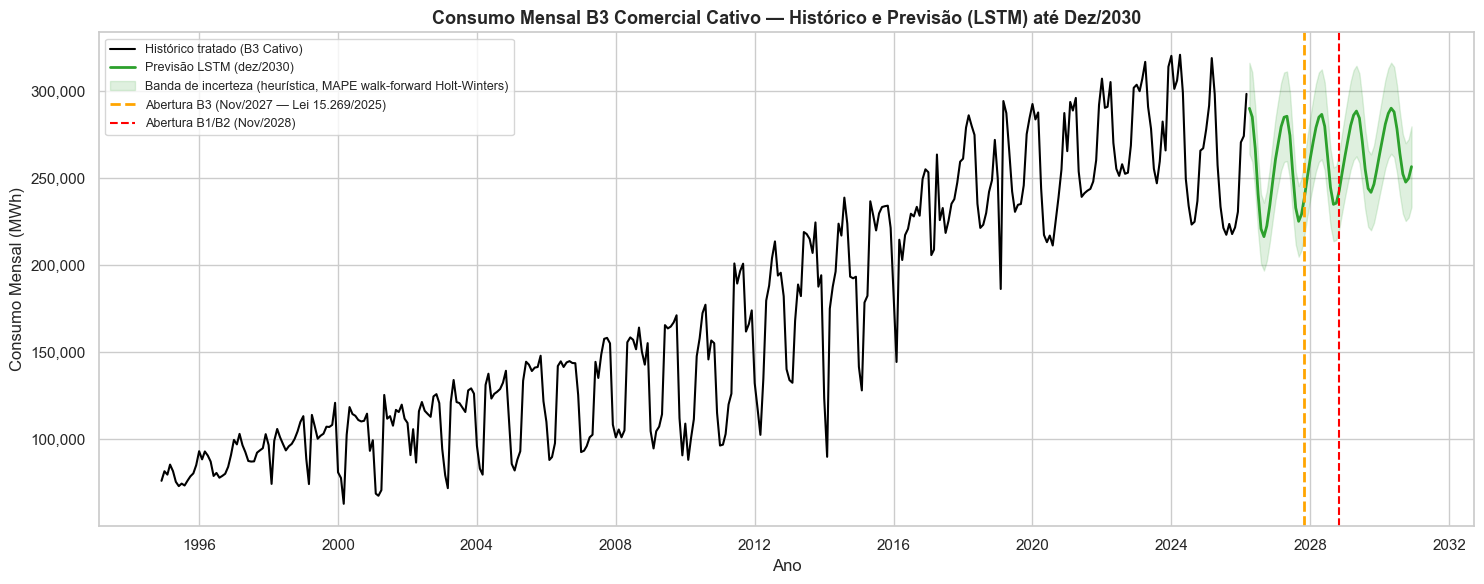

Figura salva: results/plots/03_previsao_b3_lstm_2030.png


In [7]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(ts_b3.index, ts_b3.values, label="Histórico tratado (B3 Cativo)", color="black", linewidth=1.5)
ax.plot(previsao_lstm.index, previsao_lstm.values, label="Previsão LSTM (dez/2030)", color="#2ca02c", linewidth=2)
ax.fill_between(previsao_lstm.index, banda_inferior, banda_superior,
                color="#2ca02c", alpha=0.15,
                label="Banda de incerteza (heurística, MAPE walk-forward Holt-Winters)")

ax.axvline(pd.to_datetime("2027-11-01"), color="orange", linestyle="--", linewidth=2,
           label="Abertura B3 (Nov/2027 — Lei 15.269/2025)")
ax.axvline(pd.to_datetime("2028-11-01"), color="red", linestyle="--", linewidth=1.5,
           label="Abertura B1/B2 (Nov/2028)")

ax.set_title("Consumo Mensal B3 Comercial Cativo — Histórico e Previsão (LSTM) até Dez/2030",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("Consumo Mensal (MWh)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("../results/plots/03_previsao_b3_lstm_2030.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva: results/plots/03_previsao_b3_lstm_2030.png")

In [8]:
nov2027 = previsao_lstm.get(pd.to_datetime("2027-11-01"))
dez2030 = previsao_lstm.get(pd.to_datetime("2030-12-01"))

print("=== Resumo das Projeções (LSTM, dez/1994–mar/2026 -> dez/2030) ===")
if nov2027 is not None:
    print(f"Consumo projetado Nov/2027 (abertura B3):  {nov2027:,.0f} MWh")
if dez2030 is not None:
    print(f"Consumo projetado Dez/2030 (fim do horizonte): {dez2030:,.0f} MWh")
print(f"Crescimento projetado {ts_b3.index[-1].year}-2030: {(previsao_lstm.iloc[-1] / ts_b3.iloc[-1] - 1) * 100:.1f}%")
print(
    "\nAtenção: a incerteza cresce substancialmente ao longo do horizonte (57 meses) para um modelo "
    "treinado com ~350 observações mensais — a previsão para 2029-2030 deve ser lida com cautela "
    "bem maior que a de 2026-2027 (Seção VI do relatório)."
)

=== Resumo das Projeções (LSTM, dez/1994–mar/2026 -> dez/2030) ===
Consumo projetado Nov/2027 (abertura B3):  239,091 MWh
Consumo projetado Dez/2030 (fim do horizonte): 256,733 MWh
Crescimento projetado 2026-2030: -14.0%

Atenção: a incerteza cresce substancialmente ao longo do horizonte (57 meses) para um modelo treinado com ~350 observações mensais — a previsão para 2029-2030 deve ser lida com cautela bem maior que a de 2026-2027 (Seção VI do relatório).
